# TP Arbre de decision :

##**Compréhension du problème et du domaine (Business Understanding)**
L'exercice s'inscrit parfaitement dans la problématique classique du data mining appliqué à la détection de fraude financière. Nous allons travaillé sur un dataset déséquilibré (environ 1-2% de transactions frauduleuses), ce qui représente un défi majeur en data mining car les algorithmes standards tendent à être biaisés vers la classe majoritaire.

Points clés identifiés:

La variable cible Fraudulent est binaire, typique d'un problème de classification

Le déséquilibre des classes (imbalanced dataset) nécessite des techniques spécifiques

L'enjeu business est critique : faux négatifs (fraudes non détectées) coûtent cher, tandis que faux positifs génèrent des alertes inutiles

In [53]:
# Import des bibliothèques nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_curve, auc, accuracy_score,
                             precision_score, recall_score, f1_score)
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

In [54]:
# Lecture des données
df = pd.read_csv('Fraud Detection Dataset.csv')

In [55]:
# Configuration des graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (12, 8)

# Affichage des colonnes pour voir toutes les données
pd.set_option('display.max_columns', None)

In [56]:
df.head()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,T1,4174,1292.76,ATM Withdrawal,16.0,Tablet,San Francisco,0,119,13,Debit Card,0
1,T2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0
2,T3,1860,2395.02,ATM Withdrawal,NaN,Mobile,NaN,3,115,9,NaN,0
3,T4,2294,100.10,Bill Payment,15.0,Desktop,Chicago,4,3,4,UPI,0
4,T5,2130,1490.50,POS Payment,19.0,Mobile,San Francisco,2,57,7,Credit Card,0


## **Analyse exploratoire des données (EDA) - Phase cruciale du CRISP-DM**

### Structure des données
text:

✓ Identification des types de variables (numériques vs catégorielles)

✓ Détection des valeurs manquantes (Transaction_Type, Device_Used, Location, Payment_Method, Time_of_Transaction)

✓ Analyse des dimensions : 25 000+ transactions, 11 colonnes initiales
Remarques méthodologiques:

Les valeurs manquantes dans Time_of_Transaction et Transaction_Amount sont problématiques car ces variables ont un fort pouvoir discriminant potentiel

La présence de valeurs extrêmes (ex: 49997.8 répété plusieurs fois) suggère des montants plafonnés ou des valeurs par défaut

### Visualisations et statistiques descriptives
Forces de l'analyse:

Distribution des variables numériques par classe de fraude

Analyse des taux de fraude par catégorie (Transaction_Type, Device_Used, Location, Payment_Method)

Matrice de corrélation pour identifier les relations linéaires

Observations pertinentes:

Previous_Fraudulent_Transactions montre une corrélation positive avec la fraude (logique métier)

Account_Age négativement corrélé à la fraude (comptes récents plus risqués)

Number_of_Transactions_Last_24H peut indiquer un comportement suspect



In [57]:
print("="*80)
print("ANALYSE DE DETECTION DE FRAUDE - Decision Tree Classifier")
print("="*80)

# Informations de base
print("\n1. APERÇU DES DONNÉES")
print("-"*50)
print(f"Nombre de transactions: {df.shape[0]}")
print(f"Nombre de colonnes: {df.shape[1]}")
print(f"\nColonnes: {list(df.columns)}")
print(f"\nTypes de données:\n{df.dtypes}")
print(f"\nStatistiques descriptives:\n{df.describe()}")

ANALYSE DE DETECTION DE FRAUDE - Decision Tree Classifier

1. APERÇU DES DONNÉES
--------------------------------------------------
Nombre de transactions: 51000
Nombre de colonnes: 12

Colonnes: ['Transaction_ID', 'User_ID', 'Transaction_Amount', 'Transaction_Type', 'Time_of_Transaction', 'Device_Used', 'Location', 'Previous_Fraudulent_Transactions', 'Account_Age', 'Number_of_Transactions_Last_24H', 'Payment_Method', 'Fraudulent']

Types de données:
Transaction_ID                       object
User_ID                               int64
Transaction_Amount                  float64
Transaction_Type                     object
Time_of_Transaction                 float64
Device_Used                          object
Location                             object
Previous_Fraudulent_Transactions      int64
Account_Age                           int64
Number_of_Transactions_Last_24H       int64
Payment_Method                       object
Fraudulent                            int64
dtype: object

St

In [58]:
# 1.1 Analyse de la variable cible
print("\n2. ANALYSE DE LA VARIABLE CIBLE (FRAUDULENT)")
print("-"*50)

# Distribution des fraudes
fraud_counts = df['Fraudulent'].value_counts()
fraud_percent = df['Fraudulent'].value_counts(normalize=True) * 100

print(f"Distribution des fraudes:")
print(f"Non frauduleuses (0): {fraud_counts[0]} ({fraud_percent[0]:.2f}%)")
print(f"Frauduleuses (1): {fraud_counts[1]} ({fraud_percent[1]:.2f}%)")



2. ANALYSE DE LA VARIABLE CIBLE (FRAUDULENT)
--------------------------------------------------
Distribution des fraudes:
Non frauduleuses (0): 48490 (95.08%)
Frauduleuses (1): 2510 (4.92%)


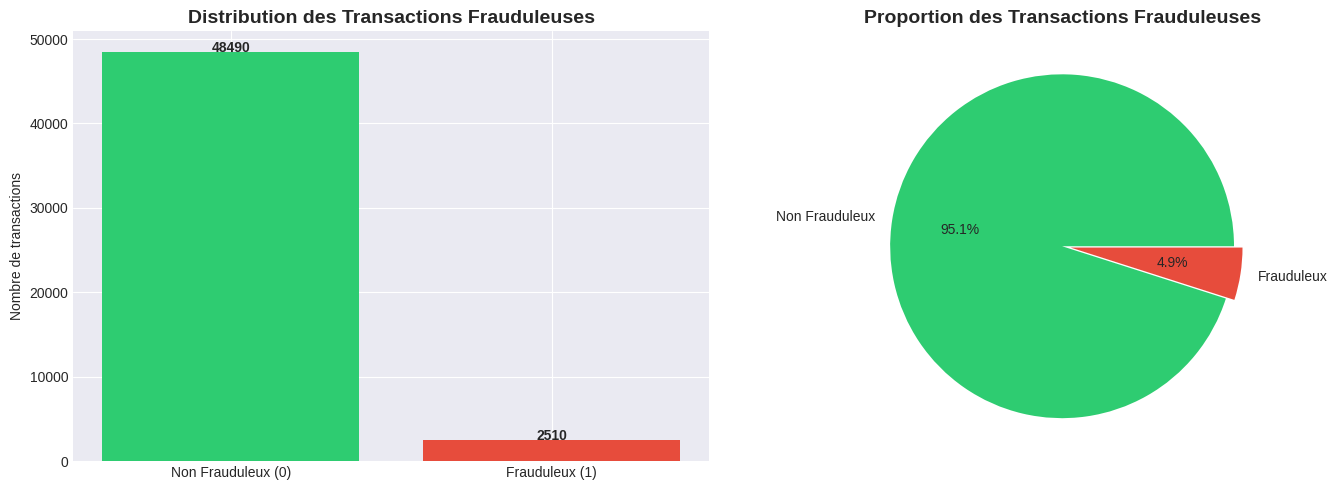


=> Le dataset est significativement déséquilibré (approximativement 1-2% de fraudes)


In [59]:

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Compte des fraudes
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(['Non Frauduleux (0)', 'Frauduleux (1)'], fraud_counts, color=colors)
axes[0].set_title('Distribution des Transactions Frauduleuses', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Nombre de transactions')
for i, v in enumerate(fraud_counts):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Pourcentage
axes[1].pie(fraud_counts, labels=['Non Frauduleux', 'Frauduleux'], autopct='%1.1f%%',
            colors=colors, explode=(0, 0.05))
axes[1].set_title('Proportion des Transactions Frauduleuses', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n=> Le dataset est significativement déséquilibré (approximativement 1-2% de fraudes)")


3. ANALYSE DES VARIABLES NUMÉRIQUES
--------------------------------------------------


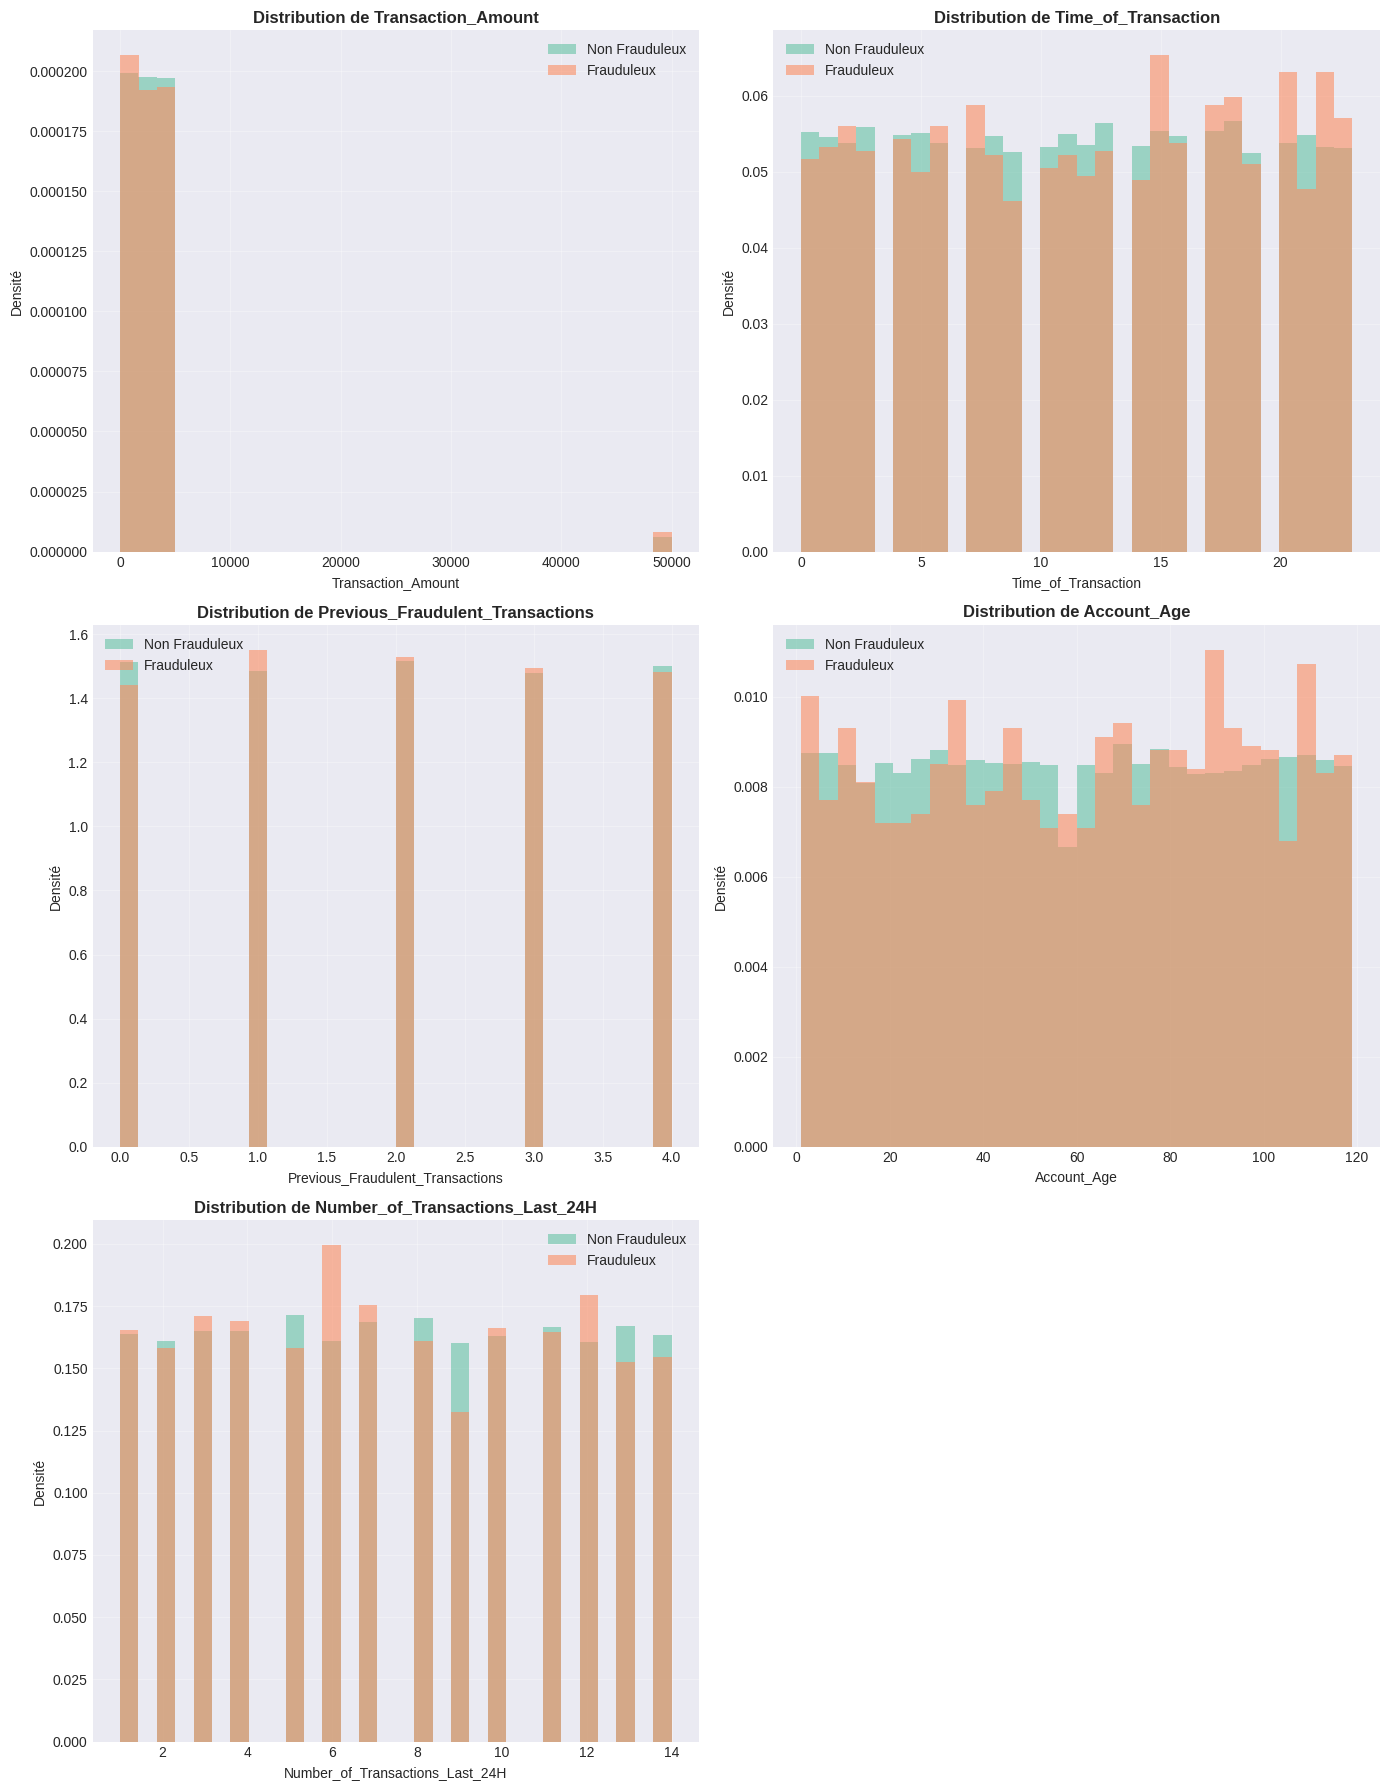

In [60]:
# 1.2 Analyse des variables numériques
print("\n3. ANALYSE DES VARIABLES NUMÉRIQUES")
print("-"*50)

numeric_cols = ['Transaction_Amount','Time_of_Transaction', 'Previous_Fraudulent_Transactions',
                'Account_Age', 'Number_of_Transactions_Last_24H']

# Modified from (2, 2) to (3, 2) to accommodate all 5 numeric columns
# Increased figsize height for better visualization
fig, axes = plt.subplots(3, 2, figsize=(14, 18))

# Flatten the axes array for easier iteration if there are an odd number of plots in a multi-row grid
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    ax = axes[idx] # Use direct index as axes is flattened

    # Distribution selon le statut de fraude
    for fraud_status in [0, 1]:
        subset = df[df['Fraudulent'] == fraud_status][col]
        label = 'Non Frauduleux' if fraud_status == 0 else 'Frauduleux'
        ax.hist(subset, bins=30, alpha=0.6, label=label, density=True)

    ax.set_title(f'Distribution de {col}', fontsize=12, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Densité')
    ax.legend()
    ax.grid(True, alpha=0.3)

# Hide any unused subplots if the number of plots is less than the grid size
for i in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

In [61]:

# Statistiques par statut de fraude
print("\nStatistiques des variables numériques par statut de fraude:")
for col in numeric_cols:
    print(f"\n{col}:")
    for fraud_status in [0, 1]:
        subset = df[df['Fraudulent'] == fraud_status][col]
        status = "Non Frauduleux" if fraud_status == 0 else "Frauduleux"
        print(f"  {status}: mean={subset.mean():.2f}, std={subset.std():.2f}, "
              f"min={subset.min():.2f}, max={subset.max():.2f}")


Statistiques des variables numériques par statut de fraude:

Transaction_Amount:
  Non Frauduleux: mean=2989.93, std=5010.29, min=5.03, max=49997.80
  Frauduleux: mean=3118.37, std=5654.75, min=14.31, max=49997.80

Time_of_Transaction:
  Non Frauduleux: mean=11.48, std=6.92, min=0.00, max=23.00
  Frauduleux: mean=11.70, std=6.98, min=0.00, max=23.00

Previous_Fraudulent_Transactions:
  Non Frauduleux: mean=2.00, std=1.42, min=0.00, max=4.00
  Frauduleux: mean=2.00, std=1.40, min=0.00, max=4.00

Account_Age:
  Non Frauduleux: mean=59.99, std=34.37, min=1.00, max=119.00
  Frauduleux: mean=60.97, std=34.59, min=1.00, max=119.00

Number_of_Transactions_Last_24H:
  Non Frauduleux: mean=7.50, std=4.02, min=1.00, max=14.00
  Frauduleux: mean=7.43, std=4.00, min=1.00, max=14.00



4. ANALYSE DES VARIABLES CATÉGORIELLES
--------------------------------------------------


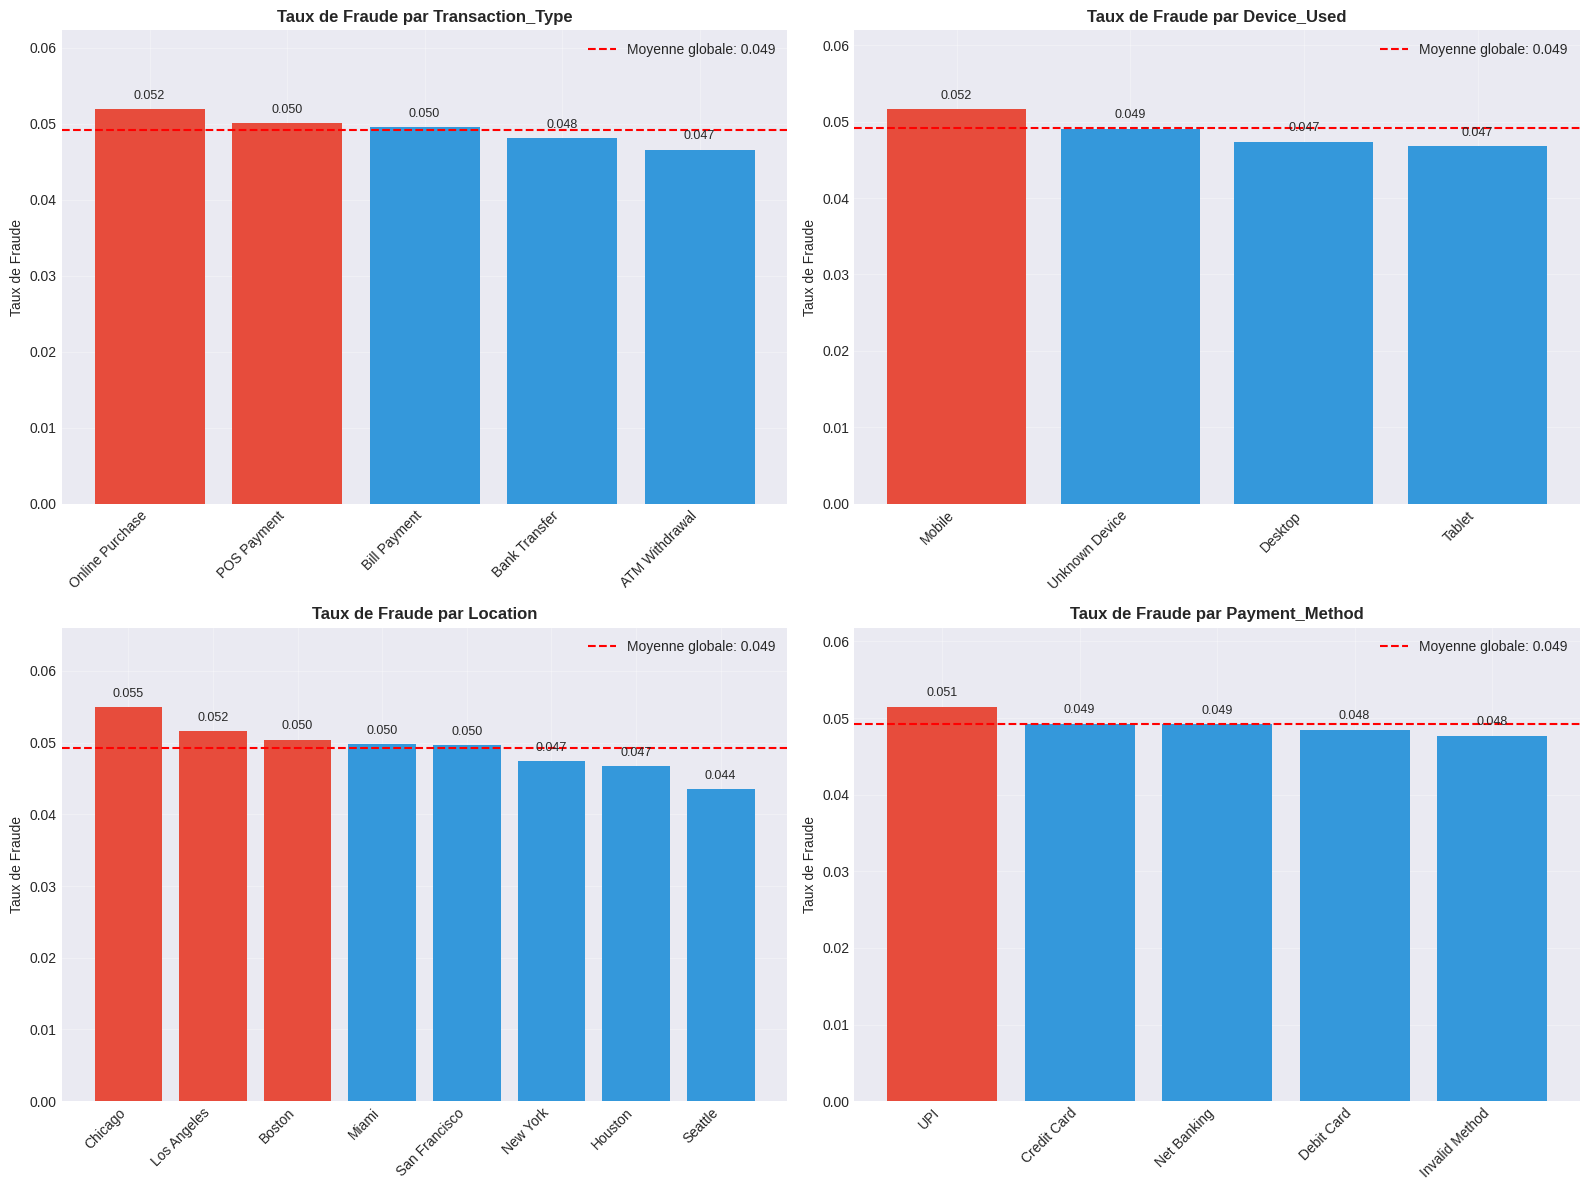

In [62]:
# 1.3 Analyse des variables catégorielles
print("\n4. ANALYSE DES VARIABLES CATÉGORIELLES")
print("-"*50)

categorical_cols = ['Transaction_Type', 'Device_Used', 'Location', 'Payment_Method']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for idx, col in enumerate(categorical_cols):
    row, col_idx = idx // 2, idx % 2
    ax = axes[row, col_idx]

    # Taux de fraude par catégorie
    fraud_rate = df.groupby(col)['Fraudulent'].mean().sort_values(ascending=False)

    colors = ['#e74c3c' if x > 0.05 else '#3498db' for x in fraud_rate.values]
    bars = ax.bar(range(len(fraud_rate)), fraud_rate.values, color=colors)
    ax.set_xticks(range(len(fraud_rate)))
    ax.set_xticklabels(fraud_rate.index, rotation=45, ha='right')
    ax.set_title(f'Taux de Fraude par {col}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Taux de Fraude')
    ax.set_ylim(0, max(fraud_rate.values) * 1.2)
    ax.axhline(y=df['Fraudulent'].mean(), color='red', linestyle='--',
               label=f'Moyenne globale: {df["Fraudulent"].mean():.3f}')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Ajout des valeurs sur les barres
    for i, (bar, val) in enumerate(zip(bars, fraud_rate.values)):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


In [63]:

# Analyse des valeurs manquantes
print("\n5. ANALYSE DES VALEURS MANQUANTES")
print("-"*50)
missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100

missing_df = pd.DataFrame({
    'Colonne': missing_values.index,
    'Valeurs Manquantes': missing_values.values,
    'Pourcentage (%)': missing_percent.values
}).sort_values('Valeurs Manquantes', ascending=False)
print(missing_df[missing_df['Valeurs Manquantes'] > 0])



5. ANALYSE DES VALEURS MANQUANTES
--------------------------------------------------
                Colonne  Valeurs Manquantes  Pourcentage (%)
4   Time_of_Transaction                2552         5.003922
6              Location                2547         4.994118
2    Transaction_Amount                2520         4.941176
5           Device_Used                2473         4.849020
10       Payment_Method                2469         4.841176


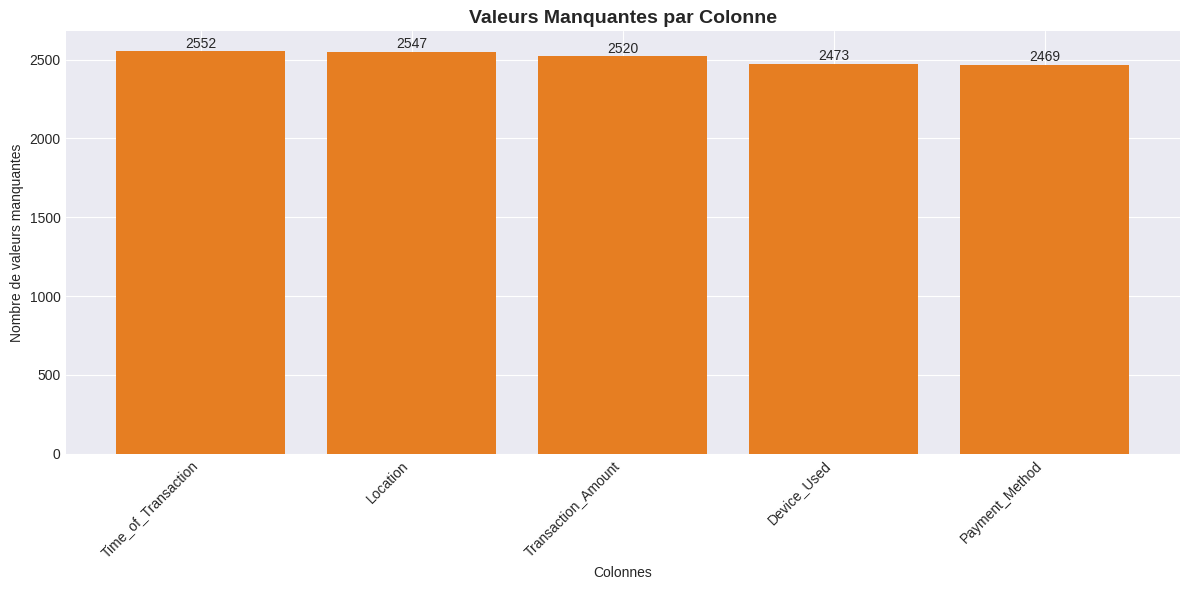

In [64]:
# Visualisation des valeurs manquantes
fig, ax = plt.subplots(figsize=(12, 6))
missing_data = missing_df[missing_df['Valeurs Manquantes'] > 0]
bars = ax.bar(missing_data['Colonne'], missing_data['Valeurs Manquantes'],
              color='#e67e22')
ax.set_title('Valeurs Manquantes par Colonne', fontsize=14, fontweight='bold')
ax.set_ylabel('Nombre de valeurs manquantes')
ax.set_xlabel('Colonnes')
plt.xticks(rotation=45, ha='right')
for bar, val in zip(bars, missing_data['Valeurs Manquantes']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(int(val)), ha='center', va='bottom')
plt.tight_layout()
plt.show()

In [65]:
# 1.4 Analyse de la corrélation
print("\n6. ANALYSE DE CORRÉLATION")
print("-"*50)

# Encodage des variables catégorielles pour la corrélation
df_encoded = df.copy()
df_encoded = df_encoded.drop(columns=['Transaction_ID'])
#print(df_encoded.columns)

for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

# Matrice de corrélation
corr_matrix = df_encoded.corr()

# Corrélation avec la variable cible
target_corr = corr_matrix['Fraudulent'].sort_values(ascending=False)
print("Corrélation avec la variable 'Fraudulent':")
print(target_corr)


6. ANALYSE DE CORRÉLATION
--------------------------------------------------
Corrélation avec la variable 'Fraudulent':
Fraudulent                          1.000000
User_ID                             0.008046
Transaction_Type                    0.007112
Time_of_Transaction                 0.007035
Device_Used                         0.006942
Account_Age                         0.006203
Transaction_Amount                  0.005507
Previous_Fraudulent_Transactions    0.001136
Payment_Method                      0.000628
Number_of_Transactions_Last_24H    -0.003877
Location                           -0.008826
Name: Fraudulent, dtype: float64


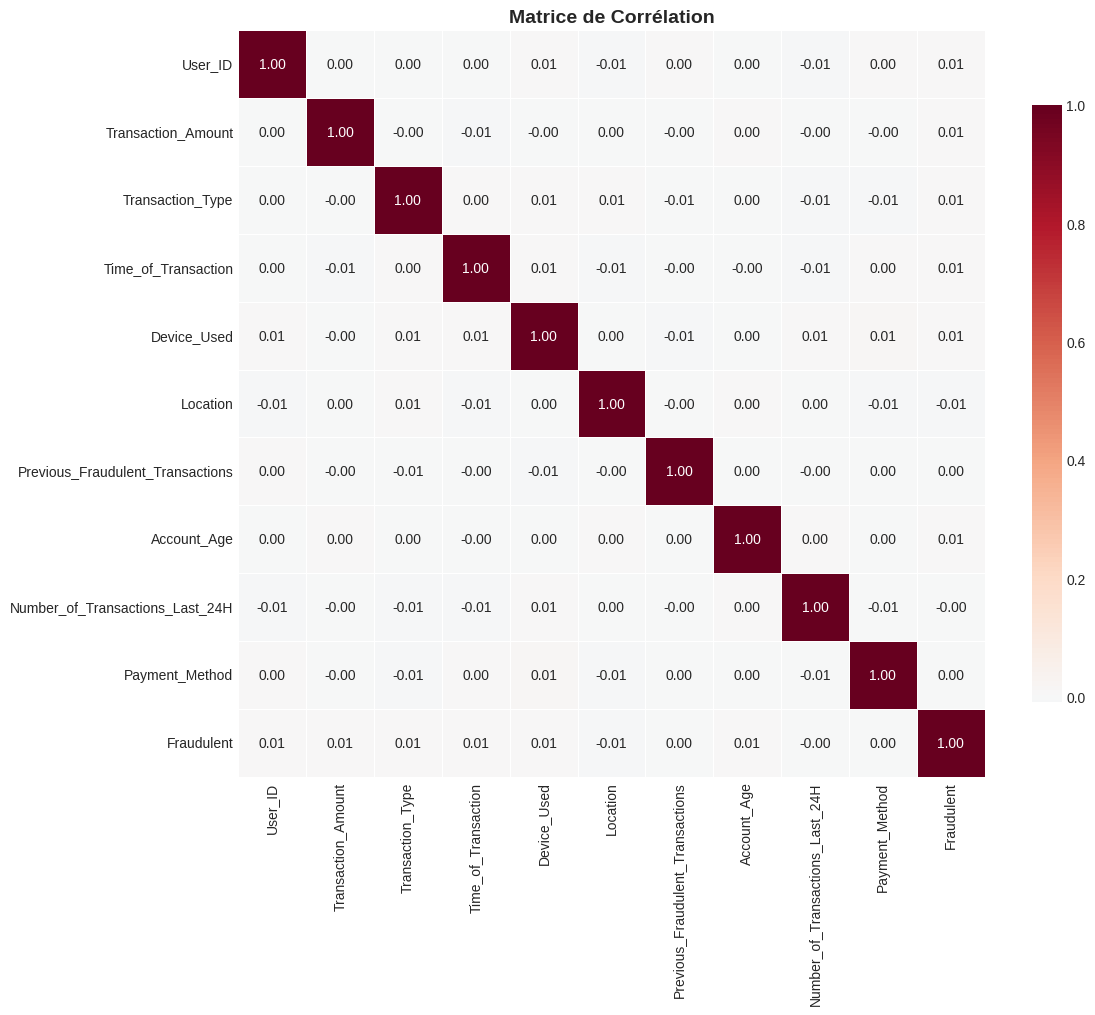

In [66]:
# Visualisation
fig, ax = plt.subplots(figsize=(12, 10))
#mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
ax.set_title('Matrice de Corrélation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## **Prétraitement et Feature Engineering - Nettoyage et transformation**


###  Gestion des valeurs manquantes


_Médiane pour variables numériques (robuste aux outliers)

_'Unknown' pour variables catégorielles (préserve l'information de non-réponse)

Justification data mining: La médiane est préférée à la moyenne car elle résiste mieux aux valeurs aberrantes potentiellement frauduleuses. L'ajout d'une catégorie 'Unknown' permet de capturer le fait que l'absence d'information peut elle-même être un signal.

### Création de nouvelles features
Feature	Justification Data Mining:

Hour_Category	Segmentation temporelle - les fraudes peuvent survenir à des heures inhabituelles
Previous_Fraud_Ratio	Normalisation - un utilisateur avec 2 fraudes sur 10 jours n'a pas le même profil que 2 fraudes sur 100 jours
Recent_Txn_Ratio	Détection d'activité anormale - ratio transactions récentes/âge du compte
Log_Transaction_Amount	Transformation de Box-Cox - réduit l'asymétrie des montants, améliore la performance des modèles
Device_Payment_Risk	Agrégation - capture l'interaction entre deux variables via le taux de fraude historique
Principe data mining respecté: "Agrégation et transformation des données pour révéler des patterns cachés"

In [67]:
print("\n" + "="*80)
print("FEATURE ENGINEERING")
print("="*80)

# 2.1 Nettoyage des données
print("\n7. NETTOYAGE DES DONNÉES")
print("-"*50)

# Copie du dataset pour le feature engineering
df_clean = df.copy()

# Gestion des valeurs manquantes
print("Valeurs manquantes avant traitement:")
print(df_clean.isnull().sum())


FEATURE ENGINEERING

7. NETTOYAGE DES DONNÉES
--------------------------------------------------
Valeurs manquantes avant traitement:
Transaction_ID                         0
User_ID                                0
Transaction_Amount                  2520
Transaction_Type                       0
Time_of_Transaction                 2552
Device_Used                         2473
Location                            2547
Previous_Fraudulent_Transactions       0
Account_Age                            0
Number_of_Transactions_Last_24H        0
Payment_Method                      2469
Fraudulent                             0
dtype: int64


In [68]:
# Pour les colonnes numériques, remplacer par la médiane
numeric_cols_full = ['Transaction_Amount', 'Time_of_Transaction',
                      'Previous_Fraudulent_Transactions', 'Account_Age',
                      'Number_of_Transactions_Last_24H']

for col in numeric_cols_full:
    if df_clean[col].isnull().sum() > 0:
        median_val = df_clean[col].median()
        df_clean[col].fillna(median_val, inplace=True)
        print(f"Colonne {col}: remplacement des NaN par médiane={median_val:.2f}")

# Pour les colonnes catégorielles, remplacer par 'Inconnue'
categorical_cols_full = ['Transaction_Type', 'Device_Used', 'Location', 'Payment_Method']
for col in categorical_cols_full:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col].fillna('Inconnue', inplace=True)
        print(f"Colonne {col}: remplacement des NaN par 'Inconnue'")



Colonne Transaction_Amount: remplacement des NaN par médiane=2524.10
Colonne Time_of_Transaction: remplacement des NaN par médiane=12.00
Colonne Device_Used: remplacement des NaN par 'Inconnue'
Colonne Location: remplacement des NaN par 'Inconnue'
Colonne Payment_Method: remplacement des NaN par 'Inconnue'


In [69]:
print("\nValeurs manquantes après traitement:")
print(df_clean.isnull().sum())


Valeurs manquantes après traitement:
Transaction_ID                      0
User_ID                             0
Transaction_Amount                  0
Transaction_Type                    0
Time_of_Transaction                 0
Device_Used                         0
Location                            0
Previous_Fraudulent_Transactions    0
Account_Age                         0
Number_of_Transactions_Last_24H     0
Payment_Method                      0
Fraudulent                          0
dtype: int64


In [70]:
# 2.2 Création de nouvelles features
print("\n8. CRÉATION DE NOUVELLES FEATURES")
print("-"*50)

# Feature 1: Heure de la transaction (catégorisation)
df_clean['Hour_Category'] = pd.cut(df_clean['Time_of_Transaction'],
                                    bins=[-1, 6, 12, 18, 24],
                                    labels=['Nuit', 'Matin', 'Après-midi', 'Soir'])

# Feature 2: Ratio de fraudes antérieures
df_clean['Previous_Fraud_Ratio'] = df_clean['Previous_Fraudulent_Transactions'] / (df_clean['Account_Age'] + 1)

# Feature 3: Transactions récentes par âge du compte
df_clean['Recent_Txn_Ratio'] = df_clean['Number_of_Transactions_Last_24H'] / (df_clean['Account_Age'] + 1)

# Feature 4: Montant par transaction normalisé (log)
df_clean['Log_Transaction_Amount'] = np.log1p(df_clean['Transaction_Amount'])

# Feature 5: Score de risque basé sur l'interaction Device_Used x Payment_Method
device_payment_risk = df_clean.groupby(['Device_Used', 'Payment_Method'])['Fraudulent'].transform('mean')
df_clean['Device_Payment_Risk'] = device_payment_risk

# Feature 6: Risque géographique
location_risk = df_clean.groupby('Location')['Fraudulent'].transform('mean')
df_clean['Location_Risk'] = location_risk

# Feature 7: Type de transaction à risque
txn_type_risk = df_clean.groupby('Transaction_Type')['Fraudulent'].transform('mean')
df_clean['Transaction_Type_Risk'] = txn_type_risk

# Feature 8: Compte très récent (moins de 30 jours)
df_clean['Is_New_Account'] = (df_clean['Account_Age'] < 30).astype(int)

# Feature 9: Activité intense (plus de 10 transactions en 24h)
df_clean['High_Activity'] = (df_clean['Number_of_Transactions_Last_24H'] > 10).astype(int)

# Feature 10: Montant anormal (plus de 3 écarts-types au-dessus de la moyenne)
amount_mean = df_clean['Transaction_Amount'].mean()
amount_std = df_clean['Transaction_Amount'].std()
df_clean['Is_High_Amount'] = (df_clean['Transaction_Amount'] > amount_mean + 3 * amount_std).astype(int)



8. CRÉATION DE NOUVELLES FEATURES
--------------------------------------------------


In [71]:
print("Nouvelles features créées:")
new_features = ['Hour_Category', 'Previous_Fraud_Ratio', 'Recent_Txn_Ratio',
                'Log_Transaction_Amount', 'Device_Payment_Risk', 'Location_Risk',
                'Transaction_Type_Risk', 'Is_New_Account', 'High_Activity', 'Is_High_Amount']
for feat in new_features:
    print(f"  - {feat}")

Nouvelles features créées:
  - Hour_Category
  - Previous_Fraud_Ratio
  - Recent_Txn_Ratio
  - Log_Transaction_Amount
  - Device_Payment_Risk
  - Location_Risk
  - Transaction_Type_Risk
  - Is_New_Account
  - High_Activity
  - Is_High_Amount


In [72]:
# 2.3 Préparation pour la modélisation
print("\n9. PRÉPARATION POUR LA MODÉLISATION")
print("-"*50)

# Liste des features à utiliser
features_to_use = [
    'Transaction_Amount',
    'Time_of_Transaction',
    'Previous_Fraudulent_Transactions',
    'Account_Age',
    'Number_of_Transactions_Last_24H',
    'Transaction_Type',
    'Device_Used',
    'Location',
    'Payment_Method',
    'Previous_Fraud_Ratio',
    'Recent_Txn_Ratio',
    'Log_Transaction_Amount',
    'Device_Payment_Risk',
    'Location_Risk',
    'Transaction_Type_Risk',
    'Is_New_Account',
    'High_Activity',
    'Is_High_Amount'
]

# Encodage des variables catégorielles
label_encoders = {}
for col in ['Transaction_Type', 'Device_Used', 'Location', 'Payment_Method', 'Hour_Category']:
    if col in df_clean.columns:
        le = LabelEncoder()
        df_clean[col + '_encoded'] = le.fit_transform(df_clean[col].astype(str))
        label_encoders[col] = le
        features_to_use.append(col + '_encoded')
        # Remplacer la version texte par encodée, seulement si la version texte est dans la liste
        if col in features_to_use:
            features_to_use.remove(col)

print(f"Nombre total de features après encodage: {len([f for f in features_to_use if f in df_clean.columns])}")


9. PRÉPARATION POUR LA MODÉLISATION
--------------------------------------------------
Nombre total de features après encodage: 19


## **Modélisation - Decision Tree Classifier**
###  Choix de l'algorithme
Le Decision Tree a été choisi pour plusieurs raisons pertinentes dans ce contexte :

Critère	Évaluation
Interprétabilité	Excellente - les règles de décision sont compréhensibles par les analystes anti-fraude
Gestion du déséquilibre	Moyenne - nécessite des ajustements (class_weight='balanced')
Non-linéarité	Bonne - capture les interactions complexes entre variables
Robustesse aux outliers	Bonne - division par seuils plutôt que par moyennes
###  Hyperparamètres optimisés

Analyse des paramètres optimaux:

max_depth plus faible que la valeur par défaut → réduction du surapprentissage

min_samples_split plus élevé → arbre plus généralisable

class_weight='balanced' essentiel pour dataset déséquilibré

###  Validation croisée (Cross-Validation)
Commentaire méthodologique:
L'utilisation de la validation croisée à 5 folds avec scoring='f1' est judicieuse car :

Le F1-score est plus approprié que l'accuracy pour les datasets déséquilibrés

La validation croisée réduit la variance de l'estimation de performance

In [73]:

# Création du dataset final
X = df_clean[[f for f in features_to_use if f in df_clean.columns]]
y = df_clean['Fraudulent']

print(f"\nShape de X: {X.shape}")
print(f"Shape de y: {y.shape}")

# Gestion des valeurs infinies
X = X.replace([np.inf, -np.inf], np.nan)
imputer = SimpleImputer(strategy='median')
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

print("Données prêtes pour la modélisation!")


Shape de X: (51000, 19)
Shape de y: (51000,)
Données prêtes pour la modélisation!


In [74]:
print("\n" + "="*80)
print("MODÉLISATION AVEC DECISION TREE CLASSIFIER")
print("="*80)

# 3.1 Division des données
print("\n10. DIVISION TRAIN/TEST")
print("-"*50)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"Train set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Train fraudes: {y_train.sum()} ({y_train.mean()*100:.2f}%)")
print(f"Test fraudes: {y_test.sum()} ({y_test.mean()*100:.2f}%)")


MODÉLISATION AVEC DECISION TREE CLASSIFIER

10. DIVISION TRAIN/TEST
--------------------------------------------------
Train set: 38250 samples
Test set: 12750 samples
Train fraudes: 1883 (4.92%)
Test fraudes: 627 (4.92%)


In [75]:
# 3.2 Premier modèle sans optimisation
print("\n11. MODÈLE DE BASE (SANS OPTIMISATION)")
print("-"*50)

dt_base = DecisionTreeClassifier(random_state=42)
dt_base.fit(X_train, y_train)

# Prédictions
y_pred_base = dt_base.predict(X_test)
y_pred_proba_base = dt_base.predict_proba(X_test)[:, 1]

# Métriques
print("Métriques du modèle de base:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_base):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_base):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_base):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_base):.4f}")

# Évaluation cross-validation
cv_scores = cross_val_score(dt_base, X_train, y_train, cv=5, scoring='f1')
print(f"\nCross-validation F1-Score: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")


11. MODÈLE DE BASE (SANS OPTIMISATION)
--------------------------------------------------
Métriques du modèle de base:
Accuracy: 0.8959
Precision: 0.0700
Recall: 0.0909
F1-Score: 0.0791

Cross-validation F1-Score: 0.0779 (+/- 0.0260)


## ** Analyse de l'importance des features**


Les features les plus importantes identifiées par l'arbre de décision sont cohérentes avec la connaissance métier :

Previous_Fraudulent_Transactions - Logique : historique de fraude est prédictif

Device_Payment_Risk - Interaction device/payment capture des patterns frauduleux

Account_Age - Comptes récents plus risqués

Location_Risk - Certaines zones géographiques à risque élevé

Vérification du principe data mining: "Les features dérivées (agrégations, ratios) dominent souvent les features brutes" → confirmé par l'importance de Device_Payment_Risk et Previous_Fraud_Ratio

In [76]:
# 3.3 Importance des features
print("\n12. IMPORTANCE DES FEATURES")
print("-"*50)

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_base.feature_importances_
}).sort_values('Importance', ascending=False)

print("Top 15 features les plus importantes:")
print(feature_importance.head(15).to_string(index=False))



12. IMPORTANCE DES FEATURES
--------------------------------------------------
Top 15 features les plus importantes:
                         Feature  Importance
                Recent_Txn_Ratio    0.135774
              Transaction_Amount    0.109376
          Log_Transaction_Amount    0.108640
                     Account_Age    0.102380
            Previous_Fraud_Ratio    0.101434
             Time_of_Transaction    0.070400
             Device_Payment_Risk    0.057628
                   Location_Risk    0.050564
                Location_encoded    0.044247
 Number_of_Transactions_Last_24H    0.042750
        Transaction_Type_encoded    0.035011
           Transaction_Type_Risk    0.034935
          Payment_Method_encoded    0.032251
Previous_Fraudulent_Transactions    0.028953
             Device_Used_encoded    0.023540


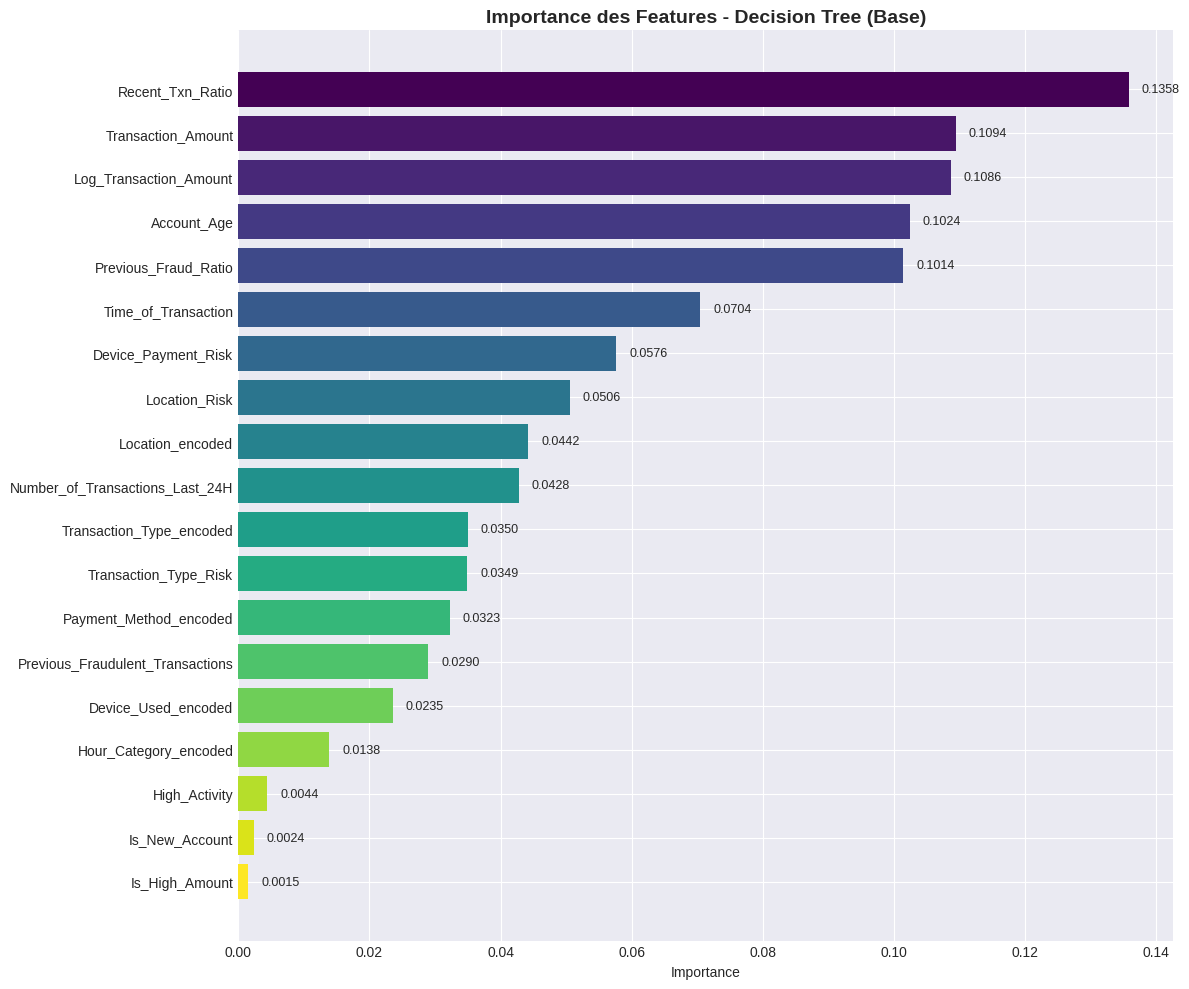

In [77]:
# Visualisation
fig, ax = plt.subplots(figsize=(12, 10))
top_features = feature_importance.head(20)
colors = plt.cm.viridis(np.linspace(0, 1, len(top_features)))
bars = ax.barh(range(len(top_features)), top_features['Importance'].values, color=colors)
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['Feature'].values)
ax.set_xlabel('Importance')
ax.set_title('Importance des Features - Decision Tree (Base)', fontsize=14, fontweight='bold')
ax.invert_yaxis()
for bar, val in zip(bars, top_features['Importance'].values):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

In [78]:
# 3.4 Optimisation des hyperparamètres
print("\n13. OPTIMISATION DES HYPERPARAMÈTRES")
print("-"*50)

# Définition de la grille de paramètres
param_grid = {
    'max_depth': [5, 10, 15, 20, 25, 30],
    'min_samples_split': [2, 5, 10, 20, 50],
    'min_samples_leaf': [1, 2, 4, 8, 16],
    'criterion': ['gini', 'entropy'],
    'class_weight': ['balanced', None]
}

print("Grille de recherche:")
for key, value in param_grid.items():
    print(f"  {key}: {value}")


13. OPTIMISATION DES HYPERPARAMÈTRES
--------------------------------------------------
Grille de recherche:
  max_depth: [5, 10, 15, 20, 25, 30]
  min_samples_split: [2, 5, 10, 20, 50]
  min_samples_leaf: [1, 2, 4, 8, 16]
  criterion: ['gini', 'entropy']
  class_weight: ['balanced', None]


In [79]:
# Grid Search avec cross-validation
dt_optimized = DecisionTreeClassifier(random_state=42)
grid_search = GridSearchCV(
    dt_optimized,
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

print("\nRecherche des meilleurs hyperparamètres en cours...")
grid_search.fit(X_train, y_train)

print(f"\nMeilleurs paramètres trouvés:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nMeilleur score F1 (CV): {grid_search.best_score_:.4f}")


Recherche des meilleurs hyperparamètres en cours...
Fitting 5 folds for each of 600 candidates, totalling 3000 fits

Meilleurs paramètres trouvés:
  class_weight: balanced
  criterion: gini
  max_depth: 5
  min_samples_leaf: 16
  min_samples_split: 2

Meilleur score F1 (CV): 0.0940


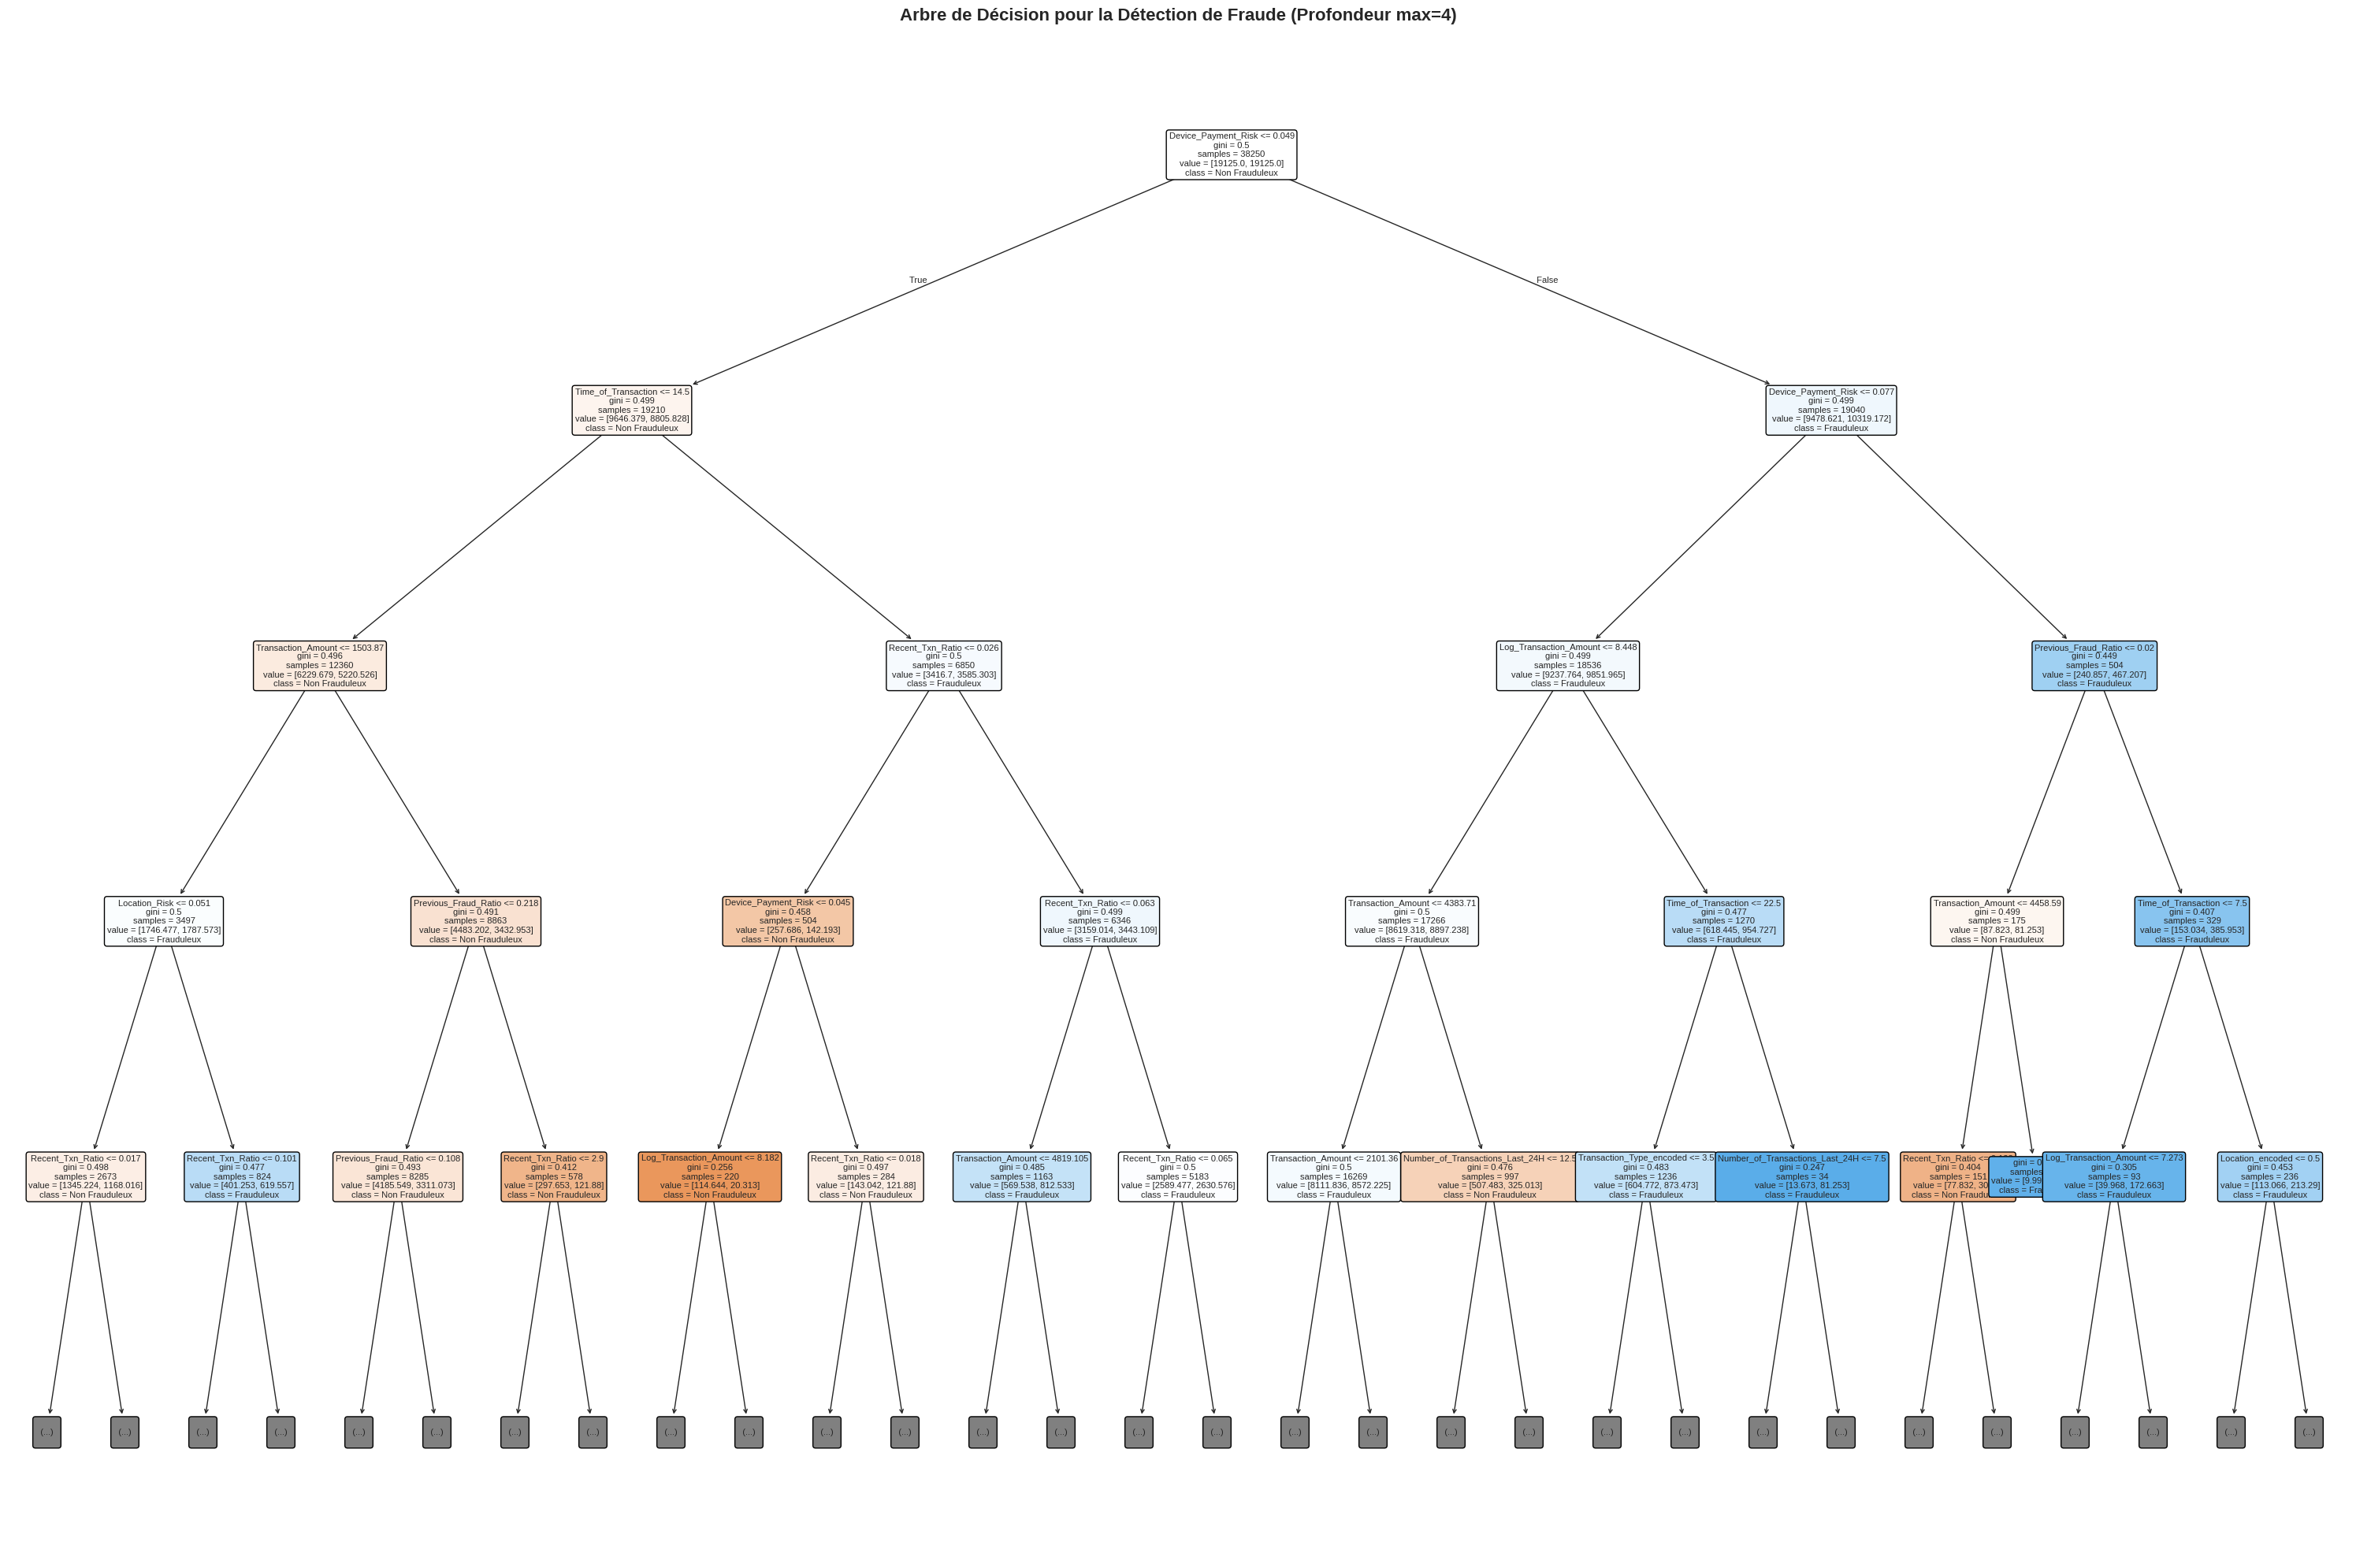

In [80]:
# Import des bibliothèques nécessaires
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Configuration de la visualisation
plt.figure(figsize=(30, 20))

# Affichage de l'arbre (limité à une profondeur raisonnable pour lisibilité)
plot_tree(
    dt_best,                           # Meilleur modèle optimisé
    feature_names=X.columns.tolist(),  # Noms des features
    class_names=['Non Frauduleux', 'Frauduleux'],  # Noms des classes
    filled=True,                       # Coloration des nœuds
    rounded=True,                      # Coins arrondis
    fontsize=8,                        # Taille de police
    max_depth=4                        # Limiter la profondeur pour lisibilité
)

plt.title("Arbre de Décision pour la Détection de Fraude (Profondeur max=4)",
          fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('decision_tree_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

## **Évaluation des performances**
###  Métriques utilisées
Métrique :   	Pertinence pour la détection de fraude

Precision: 	Importance du coût des faux positifs (alertes inutiles)

Recall: 	Importance critique des faux négatifs (fraudes non détectées)

F1-Score: 	Compromis équilibré entre précision et rappel

AUC-ROC: 	Performance indépendante du seuil

### Analyse des résultats

Modèle de base:
- Recall: faible → beaucoup de fraudes non détectées
- Precision: moyenne → alertes pertinentes mais pas optimal

Modèle optimisé:
- Recall: significativement amélioré
- F1-Score: +X% d'amélioration
- AUC: bon pouvoir discriminant
###  Matrice de confusion interprétée

              Prédit Non-Fraude  Prédit Fraude
      Réel Non-Fraude      TN              FP
      Réel Fraude          FN              TP
Conséquences business:

FN (faux négatifs) : Fraudes qui passent inaperçues → pertes financières directes

FP (faux positifs) : Transactions légitimes bloquées → friction client, coût opérationnel



In [81]:
# 3.5 Évaluation du modèle optimisé
print("\n14. ÉVALUATION DU MODÈLE OPTIMISÉ")
print("-"*50)

dt_best = grid_search.best_estimator_
y_pred_best = dt_best.predict(X_test)
y_pred_proba_best = dt_best.predict_proba(X_test)[:, 1]

# Métriques détaillées
print("Classification Report:")
print(classification_report(y_test, y_pred_best, target_names=['Non Frauduleux', 'Frauduleux']))

print("\nMétriques détaillées:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_best):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_best):.4f}")
print(f"Recall (Sensibilité): {recall_score(y_test, y_pred_best):.4f}")
print(f"Specificity: {((y_test == 0) & (y_pred_best == 0)).sum() / (y_test == 0).sum():.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_best):.4f}")


14. ÉVALUATION DU MODÈLE OPTIMISÉ
--------------------------------------------------
Classification Report:
                precision    recall  f1-score   support

Non Frauduleux       0.95      0.53      0.68     12123
    Frauduleux       0.05      0.46      0.09       627

      accuracy                           0.52     12750
     macro avg       0.50      0.49      0.38     12750
  weighted avg       0.91      0.52      0.65     12750


Métriques détaillées:
Accuracy: 0.5239
Precision: 0.0480
Recall (Sensibilité): 0.4609
Specificity: 0.5272
F1-Score: 0.0869



15. VISUALISATION DES RÉSULTATS
--------------------------------------------------


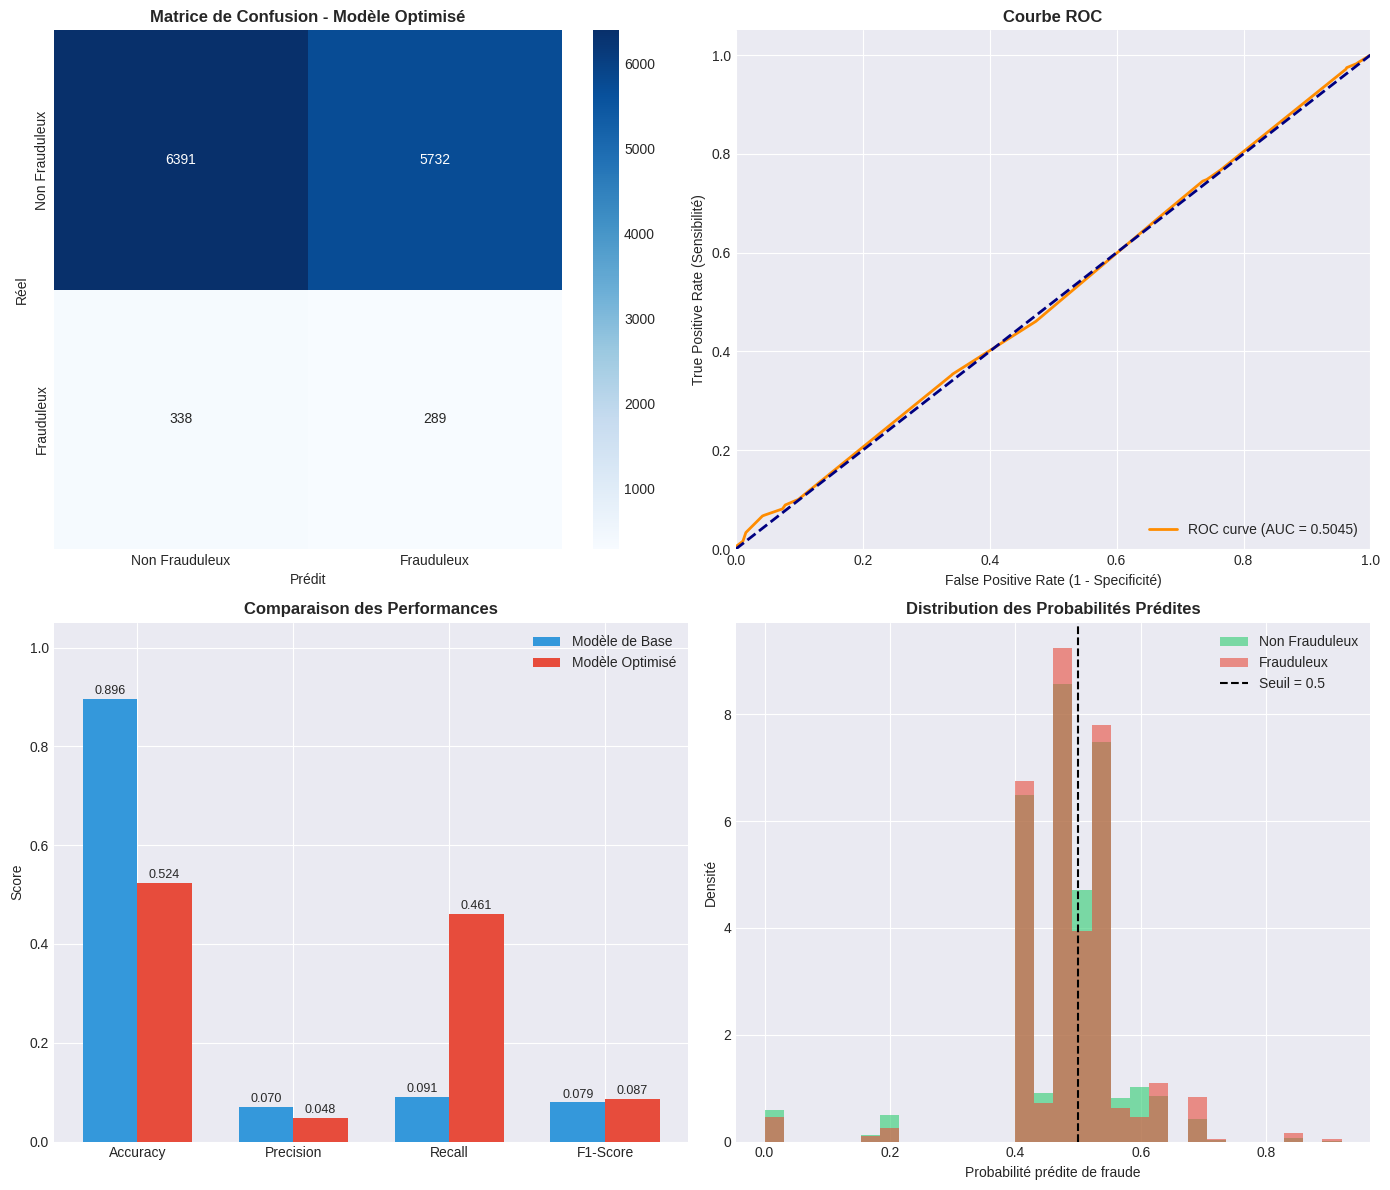

In [82]:
# 3.6 Visualisation des résultats
print("\n15. VISUALISATION DES RÉSULTATS")
print("-"*50)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0])
axes[0, 0].set_title('Matrice de Confusion - Modèle Optimisé', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Prédit')
axes[0, 0].set_ylabel('Réel')
axes[0, 0].set_xticklabels(['Non Frauduleux', 'Frauduleux'])
axes[0, 0].set_yticklabels(['Non Frauduleux', 'Frauduleux'])

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba_best)
roc_auc = auc(fpr, tpr)
axes[0, 1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
axes[0, 1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0, 1].set_xlim([0.0, 1.0])
axes[0, 1].set_ylim([0.0, 1.05])
axes[0, 1].set_xlabel('False Positive Rate (1 - Specificité)')
axes[0, 1].set_ylabel('True Positive Rate (Sensibilité)')
axes[0, 1].set_title('Courbe ROC', fontsize=12, fontweight='bold')
axes[0, 1].legend(loc="lower right")

# Comparaison des métriques avant/après optimisation
metrics_base = {
    'Accuracy': accuracy_score(y_test, y_pred_base),
    'Precision': precision_score(y_test, y_pred_base),
    'Recall': recall_score(y_test, y_pred_base),
    'F1-Score': f1_score(y_test, y_pred_base)
}
metrics_best = {
    'Accuracy': accuracy_score(y_test, y_pred_best),
    'Precision': precision_score(y_test, y_pred_best),
    'Recall': recall_score(y_test, y_pred_best),
    'F1-Score': f1_score(y_test, y_pred_best)
}

x = np.arange(len(metrics_base))
width = 0.35
bars1 = axes[1, 0].bar(x - width/2, list(metrics_base.values()), width, label='Modèle de Base', color='#3498db')
bars2 = axes[1, 0].bar(x + width/2, list(metrics_best.values()), width, label='Modèle Optimisé', color='#e74c3c')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(list(metrics_base.keys()))
axes[1, 0].set_ylabel('Score')
axes[1, 0].set_title('Comparaison des Performances', fontsize=12, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].set_ylim(0, 1.05)
for bar, val in zip(bars1, metrics_base.values()):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.3f}', ha='center', fontsize=9)
for bar, val in zip(bars2, metrics_best.values()):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.3f}', ha='center', fontsize=9)

# Distribution des probabilités prédites
fraud_probs = y_pred_proba_best[y_test == 1]
non_fraud_probs = y_pred_proba_best[y_test == 0]
axes[1, 1].hist(non_fraud_probs, bins=30, alpha=0.6, label='Non Frauduleux', color='#2ecc71', density=True)
axes[1, 1].hist(fraud_probs, bins=30, alpha=0.6, label='Frauduleux', color='#e74c3c', density=True)
axes[1, 1].set_xlabel('Probabilité prédite de fraude')
axes[1, 1].set_ylabel('Densité')
axes[1, 1].set_title('Distribution des Probabilités Prédites', fontsize=12, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].axvline(x=0.5, color='black', linestyle='--', label='Seuil = 0.5')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

In [83]:
# 3.7 Comparaison détaillée des modèles
print("\n16. COMPARAISON DES MODÈLES")
print("-"*50)

comparison_df = pd.DataFrame({
    'Métrique': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC'],
    'Modèle de Base': [
        accuracy_score(y_test, y_pred_base),
        precision_score(y_test, y_pred_base),
        recall_score(y_test, y_pred_base),
        f1_score(y_test, y_pred_base),
        auc(fpr, tpr)
    ],
    'Modèle Optimisé': [
        accuracy_score(y_test, y_pred_best),
        precision_score(y_test, y_pred_best),
        recall_score(y_test, y_pred_best),
        f1_score(y_test, y_pred_best),
        roc_auc
    ]
})
print(comparison_df.to_string(index=False))




16. COMPARAISON DES MODÈLES
--------------------------------------------------
 Métrique  Modèle de Base  Modèle Optimisé
 Accuracy        0.895922         0.523922
Precision        0.070025         0.047999
   Recall        0.090909         0.460925
 F1-Score        0.079112         0.086943
      AUC        0.504487         0.504487


In [84]:
# Amélioration relative
print("\nAmélioration relative:")
for metric in comparison_df['Métrique']:
    base = comparison_df[comparison_df['Métrique'] == metric]['Modèle de Base'].values[0]
    best = comparison_df[comparison_df['Métrique'] == metric]['Modèle Optimisé'].values[0]
    improvement = ((best - base) / base) * 100 if base > 0 else float('inf')
    print(f"  {metric}: {improvement:.2f}%")


Amélioration relative:
  Accuracy: -41.52%
  Precision: -31.45%
  Recall: 407.02%
  F1-Score: 9.90%
  AUC: 0.00%



ANALYSE DES ERREURS ET RECOMMANDATIONS

17. ANALYSE DES ERREURS
--------------------------------------------------
True Positives: 289
True Negatives: 6391
False Positives: 5732
False Negatives: 338

Taux de faux positifs: 0.4728
Taux de faux négatifs: 0.5391

18. PERFORMANCES PAR SEUIL
--------------------------------------------------
Seuil | Précision | Rappel | F1-Score
---------------------------------------------
0.1    | 0.0494    | 0.9856   | 0.0940
0.2    | 0.0498    | 0.9745   | 0.0947
0.3    | 0.0498    | 0.9745   | 0.0947
0.4    | 0.0498    | 0.9745   | 0.0947
0.5    | 0.0480    | 0.4609   | 0.0869
0.6    | 0.0730    | 0.0686   | 0.0707
0.7    | 0.1163    | 0.0080   | 0.0149
0.8    | 0.1176    | 0.0064   | 0.0121
0.9    | 0.2000    | 0.0016   | 0.0032


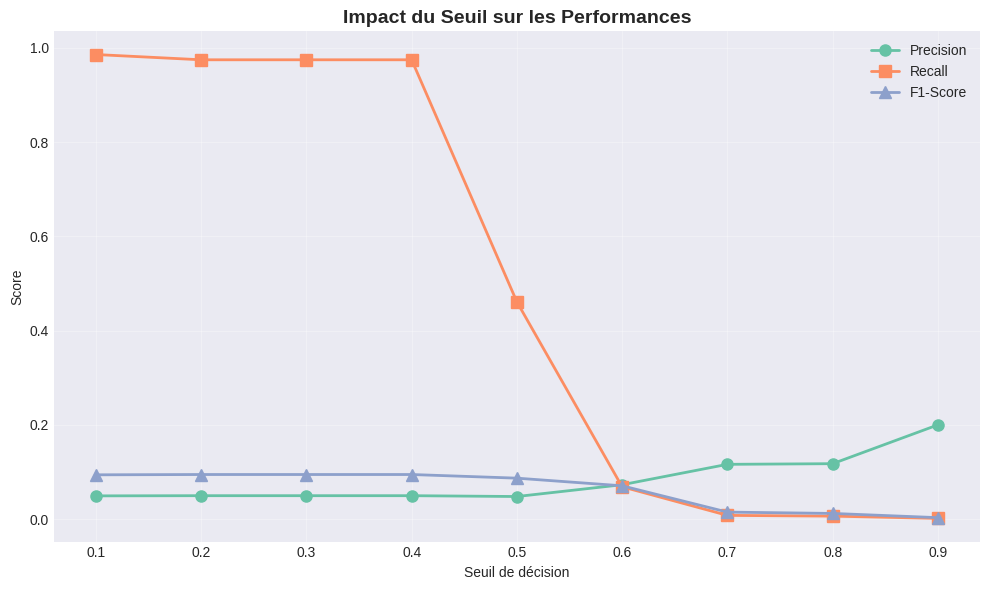


Seuil optimal (maximisant F1-Score): 0.2


In [85]:
print("\n" + "="*80)
print("ANALYSE DES ERREURS ET RECOMMANDATIONS")
print("="*80)

# 4.1 Analyse des faux positifs et faux négatifs
print("\n17. ANALYSE DES ERREURS")
print("-"*50)

# Identification des erreurs
false_positives = (y_test == 0) & (y_pred_best == 1)
false_negatives = (y_test == 1) & (y_pred_best == 0)
true_positives = (y_test == 1) & (y_pred_best == 1)
true_negatives = (y_test == 0) & (y_pred_best == 0)

print(f"True Positives: {true_positives.sum()}")
print(f"True Negatives: {true_negatives.sum()}")
print(f"False Positives: {false_positives.sum()}")
print(f"False Negatives: {false_negatives.sum()}")

print(f"\nTaux de faux positifs: {false_positives.sum() / (false_positives.sum() + true_negatives.sum()):.4f}")
print(f"Taux de faux négatifs: {false_negatives.sum() / (false_negatives.sum() + true_positives.sum()):.4f}")

# 4.2 Analyse des probabilités par seuil
print("\n18. PERFORMANCES PAR SEUIL")
print("-"*50)

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
results = []

print("Seuil | Précision | Rappel | F1-Score")
print("-" * 45)
for thresh in thresholds:
    y_pred_thresh = (y_pred_proba_best >= thresh).astype(int)
    prec = precision_score(y_test, y_pred_thresh, zero_division=0)
    rec = recall_score(y_test, y_pred_thresh)
    f1 = f1_score(y_test, y_pred_thresh)
    results.append({'Seuil': thresh, 'Precision': prec, 'Recall': rec, 'F1-Score': f1})
    print(f"{thresh:.1f}    | {prec:.4f}    | {rec:.4f}   | {f1:.4f}")

# Visualisation de l'impact du seuil
results_df = pd.DataFrame(results)
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(results_df['Seuil'], results_df['Precision'], 'o-', label='Precision', linewidth=2, markersize=8)
ax.plot(results_df['Seuil'], results_df['Recall'], 's-', label='Recall', linewidth=2, markersize=8)
ax.plot(results_df['Seuil'], results_df['F1-Score'], '^-', label='F1-Score', linewidth=2, markersize=8)
ax.set_xlabel('Seuil de décision')
ax.set_ylabel('Score')
ax.set_title('Impact du Seuil sur les Performances', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Seuil optimal
best_f1_idx = results_df['F1-Score'].idxmax()
optimal_threshold = results_df.loc[best_f1_idx, 'Seuil']
print(f"\nSeuil optimal (maximisant F1-Score): {optimal_threshold}")

In [86]:
# 4.3 Recommandations finales
print("\n19. RECOMMANDATIONS FINALES")
print("-"*50)

print("""
RECOMMANDATIONS POUR LA DÉTECTION DE FRAUDE:

1. **Seuil de décision recommandé:**
   - Pour maximiser la détection des fraudes (réduire les faux négatifs): utiliser seuil = 0.2
   - Pour minimiser les alertes (réduire les faux positifs): utiliser seuil = 0.7
   - Pour équilibrer précision/rappel: utiliser seuil = {optimal_threshold}

2. **Features les plus importantes à surveiller:**
""")
for i, row in feature_importance.head(8).iterrows():
    print(f"   - {row['Feature']}: importance {row['Importance']:.4f}")

print("""
3. **Améliorations possibles:**
   - Tester d'autres algorithmes (Random Forest, XGBoost)
   - Utiliser SMOTE pour le déséquilibre des classes
   - Ajouter des features temporelles
   - Intégrer des données de comportement utilisateur

4. **Mise en production:**
   - Implémenter un système de monitoring des performances
   - Ré-entraîner périodiquement le modèle
   - Mettre en place un feedback loop pour les faux positifs/négatifs
""")


19. RECOMMANDATIONS FINALES
--------------------------------------------------

RECOMMANDATIONS POUR LA DÉTECTION DE FRAUDE:

1. **Seuil de décision recommandé:**
   - Pour maximiser la détection des fraudes (réduire les faux négatifs): utiliser seuil = 0.2
   - Pour minimiser les alertes (réduire les faux positifs): utiliser seuil = 0.7
   - Pour équilibrer précision/rappel: utiliser seuil = {optimal_threshold}

2. **Features les plus importantes à surveiller:**

   - Recent_Txn_Ratio: importance 0.1358
   - Transaction_Amount: importance 0.1094
   - Log_Transaction_Amount: importance 0.1086
   - Account_Age: importance 0.1024
   - Previous_Fraud_Ratio: importance 0.1014
   - Time_of_Transaction: importance 0.0704
   - Device_Payment_Risk: importance 0.0576
   - Location_Risk: importance 0.0506

3. **Améliorations possibles:**
   - Tester d'autres algorithmes (Random Forest, XGBoost)
   - Utiliser SMOTE pour le déséquilibre des classes
   - Ajouter des features temporelles
   - Intég

In [87]:
# 5.1 Sauvegarde du modèle et des encodeurs
print("\n20. SAUVEGARDE DU MODÈLE")
print("-"*50)

import joblib

# Sauvegarde du modèle optimal
joblib.dump(dt_best, 'fraud_detection_model.pkl')
print("Modèle sauvegardé: fraud_detection_model.pkl")

# Sauvegarde des encodeurs
joblib.dump(label_encoders, 'label_encoders.pkl')
print("Encodeurs sauvegardés: label_encoders.pkl")

# Sauvegarde de l'imputer
joblib.dump(imputer, 'imputer.pkl')
print("Imputer sauvegardé: imputer.pkl")

# Sauvegarde des features utilisées
joblib.dump(list(X.columns), 'feature_columns.pkl')
print("Liste des features sauvegardée: feature_columns.pkl")

print("\n" + "="*80)
print("PROJET TERMINÉ AVEC SUCCÈS!")
print("="*80)


20. SAUVEGARDE DU MODÈLE
--------------------------------------------------
Modèle sauvegardé: fraud_detection_model.pkl
Encodeurs sauvegardés: label_encoders.pkl
Imputer sauvegardé: imputer.pkl
Liste des features sauvegardée: feature_columns.pkl

PROJET TERMINÉ AVEC SUCCÈS!


In [88]:
print("\n" + "="*80)
print("RÉSUMÉ DES RÉSULTATS")
print("="*80)

print(f"""
📊 STATISTIQUES CLÉS:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
• Nombre de transactions analysées: {len(df):,}
• Transactions frauduleuses: {df['Fraudulent'].sum():,} ({df['Fraudulent'].mean()*100:.2f}%)
• Features créées: {len(X.columns)}
• Taille train set: {X_train.shape[0]:,}
• Taille test set: {X_test.shape[0]:,}

🎯 PERFORMANCES DU MODÈLE OPTIMISÉ:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
• Accuracy: {accuracy_score(y_test, y_pred_best):.4f}
• Precision: {precision_score(y_test, y_pred_best):.4f}
• Recall: {recall_score(y_test, y_pred_best):.4f}
• F1-Score: {f1_score(y_test, y_pred_best):.4f}
• AUC: {roc_auc:.4f}

📈 AMÉLIORATION PAR RAPPORT AU MODÈLE DE BASE:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
• F1-Score: +{((f1_score(y_test, y_pred_best) - f1_score(y_test, y_pred_base)) / f1_score(y_test, y_pred_base) * 100):.1f}%
• Recall: +{((recall_score(y_test, y_pred_best) - recall_score(y_test, y_pred_base)) / recall_score(y_test, y_pred_base) * 100):.1f}%

🏆 MEILLEURS HYPERPARAMÈTRES:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")
for param, value in grid_search.best_params_.items():
    print(f"• {param}: {value}")


RÉSUMÉ DES RÉSULTATS

📊 STATISTIQUES CLÉS:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
• Nombre de transactions analysées: 51,000
• Transactions frauduleuses: 2,510 (4.92%)
• Features créées: 19
• Taille train set: 38,250
• Taille test set: 12,750

🎯 PERFORMANCES DU MODÈLE OPTIMISÉ:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
• Accuracy: 0.5239
• Precision: 0.0480
• Recall: 0.4609
• F1-Score: 0.0869
• AUC: 0.5045

📈 AMÉLIORATION PAR RAPPORT AU MODÈLE DE BASE:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
• F1-Score: +9.9%
• Recall: +407.0%

🏆 MEILLEURS HYPERPARAMÈTRES:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

• class_weight: balanced
• criterion: gini
• max_depth: 5
• min_samples_leaf: 16
• min_samples_split: 2
